# Level 5L6 Sensitivity Analysis: Full System + Surface Kinetics (40 Parameters)

Extends Level 5 by adding surface dissociation kinetics (Langmuir chemosorption).
- **+5 oxide surface params**: k_diss_ref, E_diss, K_eq_ref, H_eq, T_ref_surface
- **+5 metal surface params**: k_diss_metal_ref, E_diss_metal, K_eq_metal_ref, H_eq_metal, T_ref_surface_metal

**Additional output metrics**: frac_surface, frac_oxide, frac_metal, theta (surface coverage)

**Workflow:** Run Morris (500 trajectories, 40 params) → rank → focused Sobol on top 10.

In [1]:
from SALib.sample import morris as morris_sampler
from SALib.analyze import morris as morris_analyzer
from SALib.plotting import morris as morris_plotter
from SALib.sample import saltelli as sobol_sampler
from SALib.analyze import sobol as sobol_analyzer
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os, sys

parent_dir = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

In [2]:
import importlib
import numpy as np
import random
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
import validation.sensitivity_level1 as sens_module_l6
importlib.reload(sens_module_l6)

# =============================================================================
# LEVEL 6 SENSITIVITY ANALYSIS SETUP
# =============================================================================
from validation.sensitivity_level1 import (
    morris_sensitivity_level5L6,
    sobol_sensitivity_level5L6,
    plot_morris_results,
    plot_sobol_results,
    SUGGESTED_RANGES_LEVEL5L6,
    DEFAULT_PARAMS_LEVEL5L6,
    VALID_OUTPUT_METRICS_L5L6
)

# Check what we have
print(f"Number of parameters in SUGGESTED_RANGES_LEVEL5L6: {len(SUGGESTED_RANGES_LEVEL5L6)}")
print(f"\nParameters:")
for i, (param, bounds) in enumerate(SUGGESTED_RANGES_LEVEL5L6.items(), 1):
    print(f"  {i:2d}. {param:<25s}: [{bounds[0]:.2e}, {bounds[1]:.2e}]")

print(f"\nValid output metrics: {VALID_OUTPUT_METRICS_L5L6}")

Number of parameters in SUGGESTED_RANGES_LEVEL5L6: 40

Parameters:
   1. D_ref                    : [4.28e-11, 4.29e-07]
   2. E_D                      : [6.00e+04, 8.00e+04]
   3. K_s_ref                  : [1.00e-04, 1.00e-01]
   4. H_s                      : [1.00e+03, 5.00e+04]
   5. T_ref_metal              : [6.00e+02, 1.40e+03]
   6. D_ox_ref                 : [7.80e-21, 7.80e-17]
   7. E_D_ox                   : [6.90e+04, 7.10e+04]
   8. K_ox_ref                 : [8.00e-02, 4.00e-01]
   9. H_sol_ox                 : [2.00e+04, 1.70e+05]
  10. T_ref_oxide              : [6.00e+02, 1.40e+03]
  11. metal_thickness          : [5.00e-04, 5.00e-03]
  12. oxide_thickness          : [1.00e-10, 1.00e-05]
  13. P_upstream               : [1.00e-07, 1.00e+07]
  14. f_pinhole                : [1.00e-05, 1.00e-01]
  15. f_crack                  : [1.00e-05, 1.00e-01]
  16. f_gb_defect              : [1.00e-05, 1.00e-01]
  17. crack_thickness_factor   : [1.00e-02, 5.00e-01]
  18. gb_diffus

In [3]:
# =============================================================================
# MORRIS ANALYSIS: ALL VALID OUTPUT METRICS
# =============================================================================
# Run Morris screening for each output metric and store results

morris_results = {}

for output_metric in VALID_OUTPUT_METRICS_L5L6:
    print(f"\n{'#'*70}")
    print(f"# Running Morris for: {output_metric}")
    print(f"{'#'*70}")
    
    Si, problem, Y = morris_sensitivity_level5L6(
        SUGGESTED_RANGES_LEVEL5L6,
        N_trajectories=500,
        num_levels=4,
        seed=42,
        output_metric=output_metric
        
    )
    
    morris_results[output_metric] = {
        'Si': Si,
        'problem': problem,
        'Y': Y
    }
    
print("\n" + "="*70)
print("✓ Morris analysis complete for all output metrics!")
print("="*70)


######################################################################
# Running Morris for: flux
######################################################################

MORRIS SENSITIVITY ANALYSIS - LEVEL 5L6 (Surface Kinetics Model)
Running 20500 Morris samples...
Parameters (40): D_ref, E_D, K_s_ref, H_s, T_ref_metal, D_ox_ref, E_D_ox, K_ox_ref, H_sol_ox, T_ref_oxide, metal_thickness, oxide_thickness, P_upstream, f_pinhole, f_crack, f_gb_defect, crack_thickness_factor, gb_diffusivity_factor, grain_size, gb_thickness, lattice_density, trap_dislocation_E_b, trap_dislocation_N_T, trap_gb_E_b, trap_gb_N_T, trap_vacancy_E_b, trap_vacancy_N_T, trap_carbide_E_b, trap_carbide_N_T, temperature, k_diss_ref, E_diss, K_eq_ref, H_eq, T_ref_surface, k_diss_metal_ref, E_diss_metal, K_eq_metal_ref, H_eq_metal, T_ref_surface_metal
Output metric: flux



/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:613: UserWarning: Temperature 573.0 K is far outside data range [873.1, 1273.2] K. Clamping to nearest data limit for interpolation.
  warnings.warn(
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1951: UserWarning: GB traps already in trap_list, not adding automatically
  warnings.warn(msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1232: UserWarning: Reduction factor 3.32e-04 < 0.01. Diffusion essentially stopped - model may be inappropriate.
  warnings.warn(f"Reduction factor {reduction_factor:.2e} < 0.01. "
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1232: UserWarning: Reduction factor 3.30e-04 < 0.01. Diffusion essentially stopped - model may be inappropriate.
  warnings.warn(f"Reduction fact

  Completed 10/20500 samples
  Completed 20/20500 samples
  Completed 30/20500 samples
  Completed 40/20500 samples
  Completed 50/20500 samples
  Completed 60/20500 samples
  Completed 70/20500 samples
  Completed 80/20500 samples
  Completed 90/20500 samples
  Completed 100/20500 samples


/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.00×) and trapping (0.86×) nearly cancel. Small parameter changes could significantly affect results.
  warnings.warn(msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:621: UserWarning: Temperature 806.3 K is outside data range [873.1, 1273.2] K. Extrapolation may be inaccurate.
  warnings.warn(f"Temperature {T_kelvin:.1f} K is outside data range "
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1232: UserWarning: Reduction factor 3.31e-04 < 0.01. Diffusion essentially stopped - model may be inappropriate.
  warnings.warn(f"Reduction factor {reduction_factor:.2e} < 0.01. "
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1232: UserWarning: Reduction factor 1.80e-03 < 0.

  Completed 110/20500 samples
  Completed 120/20500 samples
  Completed 130/20500 samples
  Completed 140/20500 samples
  Completed 150/20500 samples
  Completed 160/20500 samples
  Completed 170/20500 samples
  Completed 180/20500 samples
  Completed 190/20500 samples
  Completed 200/20500 samples
  Completed 210/20500 samples
  Completed 220/20500 samples
  Completed 230/20500 samples
  Completed 240/20500 samples
  Completed 250/20500 samples
  Completed 260/20500 samples
  Completed 270/20500 samples
  Completed 280/20500 samples
  Completed 290/20500 samples
  Completed 300/20500 samples
  Completed 310/20500 samples
  Completed 320/20500 samples
  Completed 330/20500 samples
  Completed 340/20500 samples
  Completed 350/20500 samples
  Completed 360/20500 samples
  Completed 370/20500 samples
  Completed 380/20500 samples
  Completed 390/20500 samples
  Completed 400/20500 samples
  Completed 410/20500 samples
  Completed 420/20500 samples
  Completed 430/20500 samples


...

  Completed 20140/20500 samples
  Completed 20150/20500 samples
  Completed 20160/20500 samples
  Completed 20170/20500 samples
  Completed 20180/20500 samples
  Completed 20190/20500 samples
  Completed 20200/20500 samples
  Completed 20210/20500 samples
  Completed 20220/20500 samples
  Completed 20230/20500 samples
  Completed 20240/20500 samples
  Completed 20250/20500 samples
  Completed 20260/20500 samples
  Completed 20270/20500 samples
  Completed 20280/20500 samples
  Completed 20290/20500 samples
  Completed 20300/20500 samples
  Completed 20310/20500 samples
  Completed 20320/20500 samples
  Completed 20330/20500 samples
  Completed 20340/20500 samples
  Completed 20350/20500 samples
  Completed 20360/20500 samples
  Completed 20370/20500 samples
  Completed 20380/20500 samples


/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1232: UserWarning: Reduction factor 2.46e-03 < 0.01. Diffusion essentially stopped - model may be inappropriate.
  warnings.warn(f"Reduction factor {reduction_factor:.2e} < 0.01. "
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1232: UserWarning: Reduction factor 3.28e-04 < 0.01. Diffusion essentially stopped - model may be inappropriate.
  warnings.warn(f"Reduction factor {reduction_factor:.2e} < 0.01. "


  Completed 20390/20500 samples
  Completed 20400/20500 samples
  Completed 20410/20500 samples
  Completed 20420/20500 samples
  Completed 20430/20500 samples
  Completed 20440/20500 samples
  Completed 20450/20500 samples
  Completed 20460/20500 samples
  Completed 20470/20500 samples
  Completed 20480/20500 samples
  Completed 20490/20500 samples
  Completed 20500/20500 samples


/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1232: UserWarning: Reduction factor 6.34e-03 < 0.01. Diffusion essentially stopped - model may be inappropriate.
  warnings.warn(f"Reduction factor {reduction_factor:.2e} < 0.01. "
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1232: UserWarning: Reduction factor 1.40e-03 < 0.01. Diffusion essentially stopped - model may be inappropriate.
  warnings.warn(f"Reduction factor {reduction_factor:.2e} < 0.01. "




  Morris analysis complete
  Output range: [1.95e-25, 2.15e+02]
    1. H_s: μ = 1.57e+00
    2. K_s_ref: μ = 7.80e-01
    3. T_ref_metal: μ = -6.98e-01
    4. k_diss_metal_ref: μ = 5.95e-01
    5. temperature: μ = 4.23e-01
    6. K_eq_metal_ref: μ = -3.50e-01
    7. T_ref_surface_metal: μ = -3.44e-01
    8. P_upstream: μ = 3.40e-01
    9. D_ref: μ = 2.93e-01
    10. E_diss_metal: μ = 2.62e-01

######################################################################
# Running Morris for: permeability
######################################################################

MORRIS SENSITIVITY ANALYSIS - LEVEL 5L6 (Surface Kinetics Model)
Running 20500 Morris samples...
Parameters (40): D_ref, E_D, K_s_ref, H_s, T_ref_metal, D_ox_ref, E_D_ox, K_ox_ref, H_sol_ox, T_ref_oxide, metal_thickness, oxide_thickness, P_upstream, f_pinhole, f_crack, f_gb_defect, crack_thickness_factor, gb_diffusivity_factor, grain_size, gb_thickness, lattice_density, trap_dislocation_E_b, trap_dislocation_N_T, trap_g

In [4]:
morris_results

{'flux': {'Si': {'names': array(['D_ref', 'E_D', 'K_s_ref', 'H_s', 'T_ref_metal', 'D_ox_ref',
          'E_D_ox', 'K_ox_ref', 'H_sol_ox', 'T_ref_oxide', 'metal_thickness',
          'oxide_thickness', 'P_upstream', 'f_pinhole', 'f_crack',
          'f_gb_defect', 'crack_thickness_factor', 'gb_diffusivity_factor',
          'grain_size', 'gb_thickness', 'lattice_density',
          'trap_dislocation_E_b', 'trap_dislocation_N_T', 'trap_gb_E_b',
          'trap_gb_N_T', 'trap_vacancy_E_b', 'trap_vacancy_N_T',
          'trap_carbide_E_b', 'trap_carbide_N_T', 'temperature',
          'k_diss_ref', 'E_diss', 'K_eq_ref', 'H_eq', 'T_ref_surface',
          'k_diss_metal_ref', 'E_diss_metal', 'K_eq_metal_ref', 'H_eq_metal',
          'T_ref_surface_metal'], dtype='<U22'),
   'mu': masked_array(data=[0.29293898375366373, 0.06400406670886997,
                      0.7795529923013327, 1.569400514039282,
                      -0.6976817043652509, 0.0013731972043685133,
                      0.0001


OUTPUT: flux


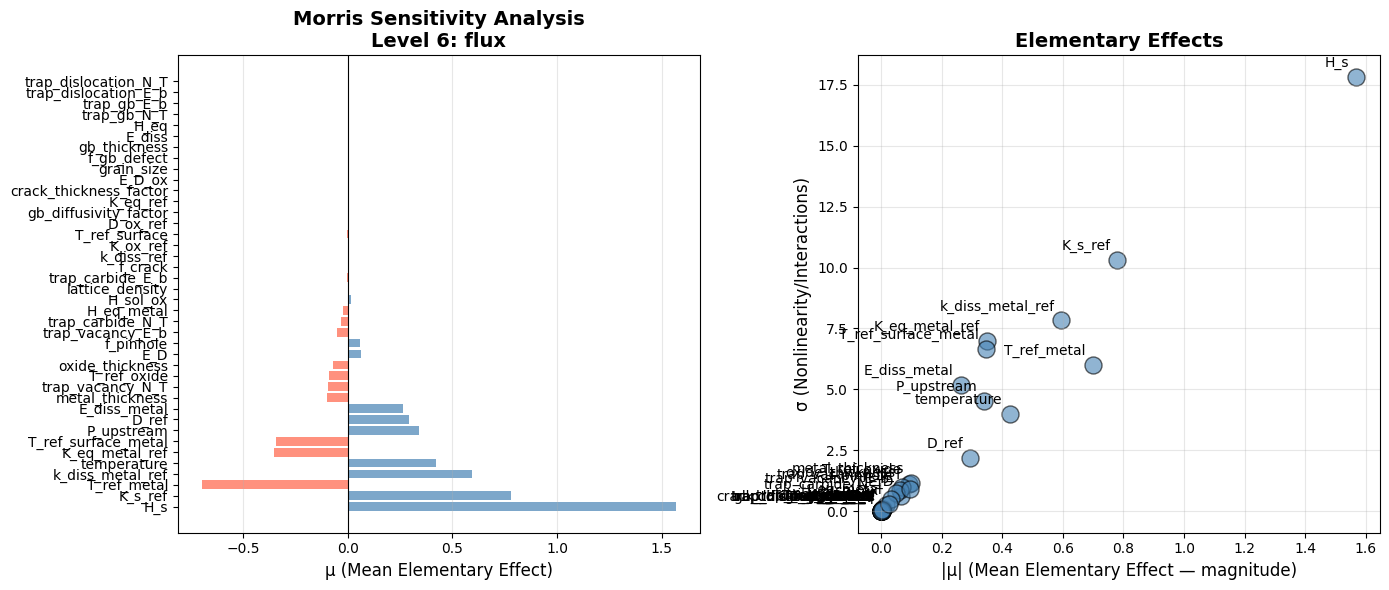


MORRIS SENSITIVITY RESULTS - Level 6: flux
             Parameter             μ            σ       μ_conf
                   H_s  1.569401e+00 1.782607e+01 1.524059e+00
               K_s_ref  7.795530e-01 1.030813e+01 8.803724e-01
           T_ref_metal -6.976817e-01 6.005420e+00 5.055575e-01
      k_diss_metal_ref  5.949965e-01 7.827860e+00 7.488116e-01
           temperature  4.233344e-01 3.990431e+00 3.582318e-01
        K_eq_metal_ref -3.500283e-01 6.985821e+00 5.732225e-01
   T_ref_surface_metal -3.443773e-01 6.654248e+00 5.603394e-01
            P_upstream  3.404181e-01 4.521218e+00 4.125243e-01
                 D_ref  2.929390e-01 2.189500e+00 1.981798e-01
          E_diss_metal  2.617968e-01 5.165690e+00 4.344345e-01
       metal_thickness -9.759692e-02 1.166772e+00 9.281293e-02
      trap_vacancy_N_T -9.508579e-02 9.208584e-01 9.016138e-02
           T_ref_oxide -8.953653e-02 1.124874e+00 9.759832e-02
       oxide_thickness -6.890362e-02 1.001319e+00 8.348060e-02
           

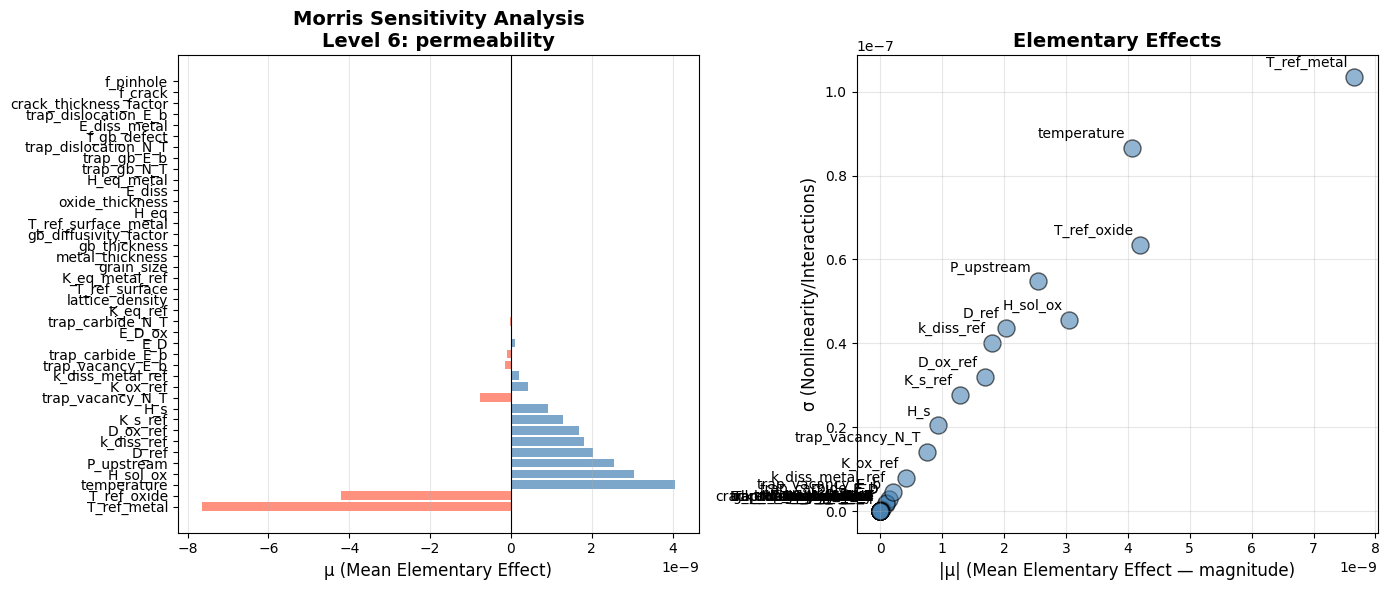


MORRIS SENSITIVITY RESULTS - Level 6: permeability
             Parameter             μ            σ       μ_conf
           T_ref_metal -7.654380e-09 1.034780e-07 8.367208e-09
           T_ref_oxide -4.192462e-09 6.349718e-08 5.279550e-09
           temperature  4.067359e-09 8.661759e-08 7.628939e-09
              H_sol_ox  3.054671e-09 4.549615e-08 3.715038e-09
            P_upstream  2.548575e-09 5.472616e-08 4.705674e-09
                 D_ref  2.033668e-09 4.363262e-08 3.831292e-09
            k_diss_ref  1.812401e-09 4.011978e-08 3.664838e-09
              D_ox_ref  1.687905e-09 3.194506e-08 2.815622e-09
               K_s_ref  1.282396e-09 2.771138e-08 2.583317e-09
                   H_s  9.268042e-10 2.039961e-08 1.888249e-09
      trap_vacancy_N_T -7.621773e-10 1.413775e-08 1.112147e-09
              K_ox_ref  4.187452e-10 7.770658e-09 6.795250e-10
      k_diss_metal_ref  2.071606e-10 4.448445e-09 3.747955e-10
      trap_vacancy_E_b -1.362634e-10 2.919237e-09 2.272576e-10
   

In [5]:
# =============================================================================
# PLOT MORRIS RESULTS FOR ALL OUTPUTS
# =============================================================================

for output_metric in VALID_OUTPUT_METRICS_L5L6:
    print(f"\n{'='*70}")
    print(f"OUTPUT: {output_metric}")
    print(f"{'='*70}")
    
    Si = morris_results[output_metric]['Si']
    problem = morris_results[output_metric]['problem']
    
    plot_morris_results(Si, problem, f'Level 6: {output_metric}')

In [6]:
# =============================================================================
# PARAMETER IMPORTANCE RANKING ACROSS ALL 11 OUTPUTS
# =============================================================================
import pandas as pd

param_names = morris_results['flux']['problem']['names']

# Build DataFrame with μ for each output
df_all = pd.DataFrame({'Parameter': param_names})

for output_metric in VALID_OUTPUT_METRICS_L5L6:
    df_all[f'μ_{output_metric}'] = morris_results[output_metric]['Si']['mu_star']

# Normalize each column
for output_metric in VALID_OUTPUT_METRICS_L5L6:
    col = f'μ_{output_metric}'
    max_val = df_all[col].abs().max()
    if max_val > 0:
        df_all[f'{col}_norm'] = df_all[col] / max_val
    else:
        df_all[f'{col}_norm'] = 0

# Average normalized importance across all outputs
norm_cols = [f'μ_{m}_norm' for m in VALID_OUTPUT_METRICS_L5L6]
df_all['Avg_Importance'] = df_all[norm_cols].mean(axis=1)
df_all = df_all.sort_values('Avg_Importance', ascending=False)

# Display summary
print("="*100)
print("PARAMETER IMPORTANCE RANKING (Morris μ - All 11 Outputs)")
print("="*100)
display_cols = ['Parameter'] + [f'μ_{m}' for m in VALID_OUTPUT_METRICS_L5L6] + ['Avg_Importance']
print(df_all[display_cols].to_string(index=False))
print("="*100)

# Top 10 for Sobol
top_10 = df_all.head(10)['Parameter'].tolist()
print(f"\n→ Top 10 parameters for focused Sobol analysis:")
for i, p in enumerate(top_10, 1):
    importance = df_all[df_all['Parameter'] == p]['Avg_Importance'].values[0]


PARAMETER IMPORTANCE RANKING (Morris μ - All 11 Outputs)
             Parameter       μ_flux  μ_permeability  Avg_Importance
           T_ref_metal 6.976817e-01    7.801052e-09    7.222730e-01
                   H_s 1.569425e+00    9.303689e-10    5.596310e-01
           temperature 4.233344e-01    4.067359e-09    3.955623e-01
               K_s_ref 7.795530e-01    1.282419e-09    3.305515e-01
           T_ref_oxide 8.953653e-02    4.192462e-09    2.972366e-01
            P_upstream 3.404181e-01    2.548575e-09    2.718013e-01
                 D_ref 2.929390e-01    2.033670e-09    2.236727e-01
      k_diss_metal_ref 5.949965e-01    2.071606e-10    2.028365e-01
              H_sol_ox 1.405119e-02    3.054953e-09    2.002805e-01
            k_diss_ref 2.318663e-03    1.812401e-09    1.169026e-01
        K_eq_metal_ref 3.500283e-01    1.458076e-14    1.115158e-01
   T_ref_surface_metal 3.443773e-01    2.599840e-18    1.097145e-01
              D_ox_ref 1.373197e-03    1.687905e-09    1.08

### Sensitivity Heatmap

Top 20 parameters across all 6 output metrics. Yellow = low sensitivity, Red = high sensitivity.

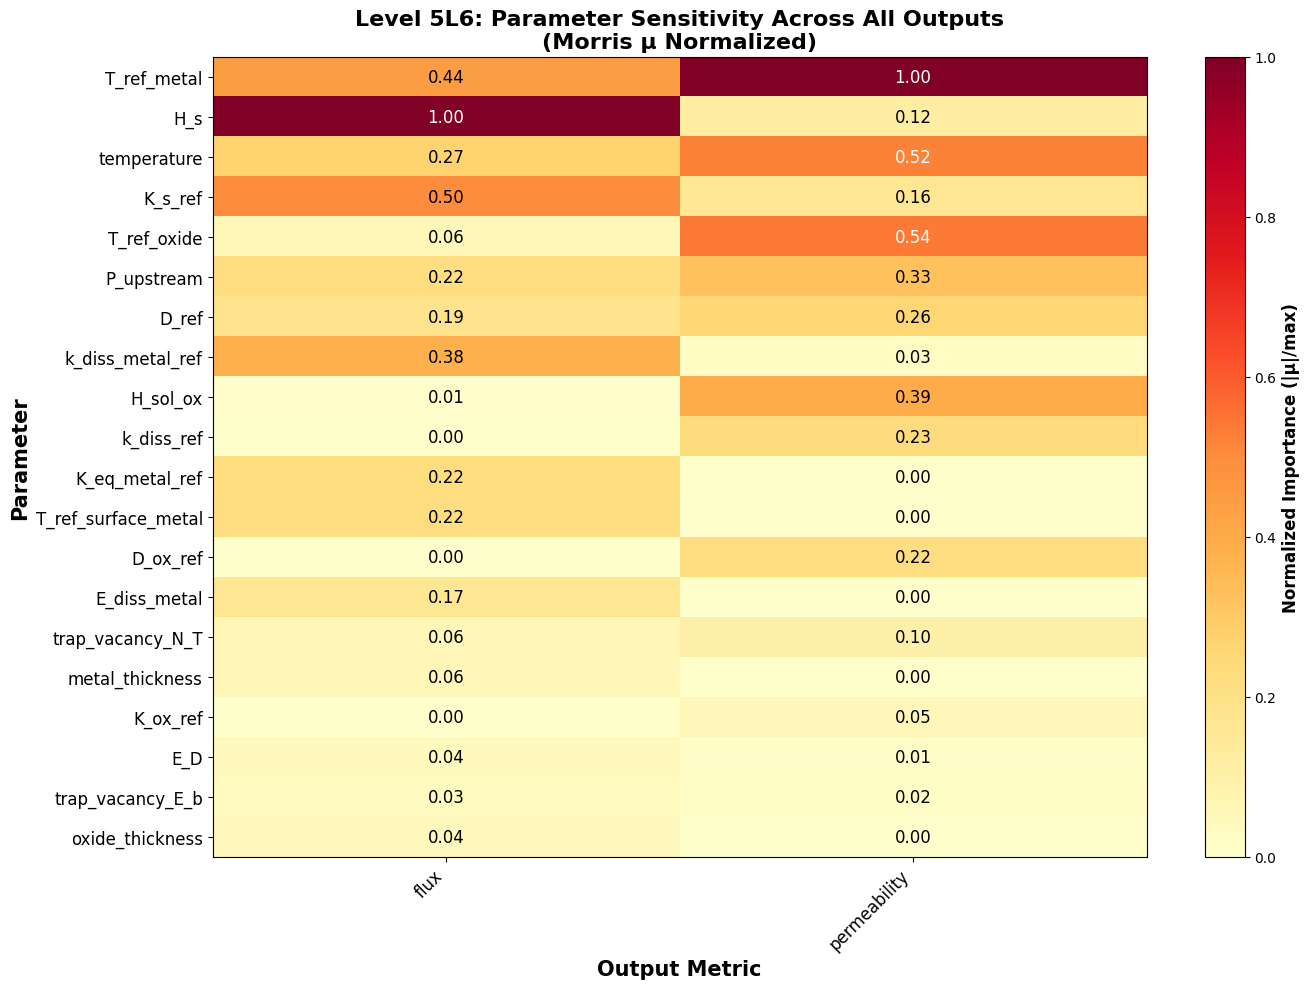

In [7]:
# =============================================================================
# HEATMAP: Parameter Importance Across All Outputs
# =============================================================================
import matplotlib.pyplot as plt
import numpy as np

# Get top 20 parameters for visualization
top_20 = df_all.head(20)

# Extract normalized values for heatmap
heatmap_data = top_20[[f'μ_{m}_norm' for m in VALID_OUTPUT_METRICS_L5L6]].values
param_labels = top_20['Parameter'].tolist()
output_labels = VALID_OUTPUT_METRICS_L5L6

fig, ax = plt.subplots(figsize=(14, 10))

im = ax.imshow(heatmap_data, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)

# Labels
ax.set_xticks(np.arange(len(output_labels)))
ax.set_yticks(np.arange(len(param_labels)))
ax.set_xticklabels(output_labels, rotation=45, ha='right', fontsize=12)
ax.set_yticklabels(param_labels, fontsize=12)

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Normalized Importance (|μ|/max)', fontsize=12, fontweight='bold')

# Annotate cells with values
for i in range(len(param_labels)):
    for j in range(len(output_labels)):
        val = heatmap_data[i, j]
        color = 'white' if val > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', color=color, fontsize=12)

ax.set_title('Level 5L6: Parameter Sensitivity Across All Outputs\n(Morris μ Normalized)', 
             fontsize=16, fontweight='bold')
ax.set_xlabel('Output Metric', fontsize=15, fontweight='bold')
ax.set_ylabel('Parameter', fontsize=15, fontweight='bold')

plt.tight_layout()


# Sobol Analysis


In [8]:
# =============================================================================
# CREATE FOCUSED RANGES FOR SOBOL (Top 10 from Morris Heatmap)
# =============================================================================

# top_10 already exists from the ranking cell above
SOBOL_FOCUSED_RANGES = {param: SUGGESTED_RANGES_LEVEL5L6[param] for param in top_10}

print("="*70)
print("FOCUSED PARAMETER RANGES FOR SOBOL (Top 10 from Heatmap)")
print("="*70)
for i, (param, bounds) in enumerate(SOBOL_FOCUSED_RANGES.items(), 1):
    importance = df_all[df_all['Parameter'] == param]['Avg_Importance'].values[0]
    print(f"  {i:2d}. {param:<25s}: [{bounds[0]:.2e}, {bounds[1]:.2e}]  (μ={importance:.3f})")
print("="*70)

FOCUSED PARAMETER RANGES FOR SOBOL (Top 10 from Heatmap)
   1. T_ref_metal              : [6.00e+02, 1.40e+03]  (μ=0.722)
   2. H_s                      : [1.00e+03, 5.00e+04]  (μ=0.560)
   3. temperature              : [5.73e+02, 1.27e+03]  (μ=0.396)
   4. K_s_ref                  : [1.00e-04, 1.00e-01]  (μ=0.331)
   5. T_ref_oxide              : [6.00e+02, 1.40e+03]  (μ=0.297)
   6. P_upstream               : [1.00e-07, 1.00e+07]  (μ=0.272)
   7. D_ref                    : [4.28e-11, 4.29e-07]  (μ=0.224)
   8. k_diss_metal_ref         : [1.35e-08, 1.35e-04]  (μ=0.203)
   9. H_sol_ox                 : [2.00e+04, 1.70e+05]  (μ=0.200)
  10. k_diss_ref               : [9.49e-10, 9.49e-06]  (μ=0.117)


In [9]:
# =============================================================================
# SOBOL ANALYSIS: TOP 10 PARAMETERS (from Morris screening)
# =============================================================================
# Set random seeds for reproducibility


sobol_results = {}

for output_metric in VALID_OUTPUT_METRICS_L5L6:
    print(f"\n{'#'*70}")
    print(f"# Running Sobol for: {output_metric}")
    print(f"{'#'*70}")
    
    Si, problem, Y = sobol_sensitivity_level5L6(
        SOBOL_FOCUSED_RANGES,  # Use focused ranges from Morris top 10
        N_samples=1024,              # Samples (total = N × (2D + 2) = 22,528)
        output_metric=output_metric
        
        
    )
  
    sobol_results[output_metric] = {
        'Si': Si,
        'problem': problem,
        'Y': Y
    }

print("\n" + "="*70)
print("✓ Sobol analysis complete for all output metrics!")
print("="*70)


######################################################################
# Running Sobol for: flux
######################################################################

SOBOL SENSITIVITY ANALYSIS - LEVEL 5L6 (Surface Kinetics Model)
Running 22528 Sobol samples (N_base=1024, 10 params)
Parameters: T_ref_metal, H_s, temperature, K_s_ref, T_ref_oxide, P_upstream, D_ref, k_diss_metal_ref, H_sol_ox, k_diss_ref
Output metric: flux



/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1951: UserWarning: GB traps already in trap_list, not adding automatically
  warnings.warn(msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.00×) and trapping (0.89×) nearly cancel. Small parameter changes could significantly affect results.
  warnings.warn(msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.00×) and trapping (0.94×) nearly cancel. Small parameter changes could significantly affect results.
  warnings.warn(msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:621: UserWarning: Temperature 717.6 K is outside data range [873.1, 1273.2] K. Extrapolation may be inaccurate.
  warnings.warn(f"Temperature {T_kelvin:.1f} K

  Completed 2252/22528 samples (10%)


/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:613: UserWarning: Temperature 613.7 K is far outside data range [873.1, 1273.2] K. Clamping to nearest data limit for interpolation.
  warnings.warn(
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:621: UserWarning: Temperature 832.4 K is outside data range [873.1, 1273.2] K. Extrapolation may be inaccurate.
  warnings.warn(f"Temperature {T_kelvin:.1f} K is outside data range "
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:621: UserWarning: Temperature 848.1 K is outside data range [873.1, 1273.2] K. Extrapolation may be inaccurate.
  warnings.warn(f"Temperature {T_kelvin:.1f} K is outside data range "
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:613: UserWarning: Temperature 657.4 K is far outside dat

  Completed 4504/22528 samples (20%)


...

  Completed 6756/22528 samples (30%)


/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:621: UserWarning: Temperature 756.5 K is outside data range [873.1, 1273.2] K. Extrapolation may be inaccurate.
  warnings.warn(f"Temperature {T_kelvin:.1f} K is outside data range "
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:621: UserWarning: Temperature 760.0 K is outside data range [873.1, 1273.2] K. Extrapolation may be inaccurate.
  warnings.warn(f"Temperature {T_kelvin:.1f} K is outside data range "
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:613: UserWarning: Temperature 581.5 K is far outside data range [873.1, 1273.2] K. Clamping to nearest data limit for interpolation.
  warnings.warn(
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:613: UserWarning: Temperature 585.0 K is far outside dat

  Completed 9008/22528 samples (40%)


/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:613: UserWarning: Temperature 573.3 K is far outside data range [873.1, 1273.2] K. Clamping to nearest data limit for interpolation.
  warnings.warn(
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:613: UserWarning: Temperature 609.6 K is far outside data range [873.1, 1273.2] K. Clamping to nearest data limit for interpolation.
  warnings.warn(
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:621: UserWarning: Temperature 748.3 K is outside data range [873.1, 1273.2] K. Extrapolation may be inaccurate.
  warnings.warn(f"Temperature {T_kelvin:.1f} K is outside data range "
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:621: UserWarning: Temperature 792.1 K is outside data range [873.1, 1273.2] K. Extrapolat

  Completed 11260/22528 samples (50%)
  Completed 13512/22528 samples (60%)
  Completed 15764/22528 samples (70%)
  Completed 18016/22528 samples (80%)
  Completed 20268/22528 samples (90%)
  Completed 22520/22528 samples (100%)
  Completed 22528/22528 samples (100%)

  Sobol analysis complete
  Output range: [2.18e-13, 1.33e+01]

  Parameter                       S1       ST
  ------------------------- -------- --------
  T_ref_metal                  0.042    0.607
  H_s                          0.015    0.510
  temperature                  0.062    0.471
  T_ref_oxide                  0.021    0.226
  D_ref                       -0.003    0.095
  K_s_ref                      0.003    0.077
  P_upstream                   0.004    0.050
  k_diss_metal_ref             0.001    0.040
  H_sol_ox                     0.001    0.024
  k_diss_ref                   0.000    0.000

  Sum(S1)=0.146  Sum(ST)=2.101

######################################################################
# Running S


OUTPUT: flux


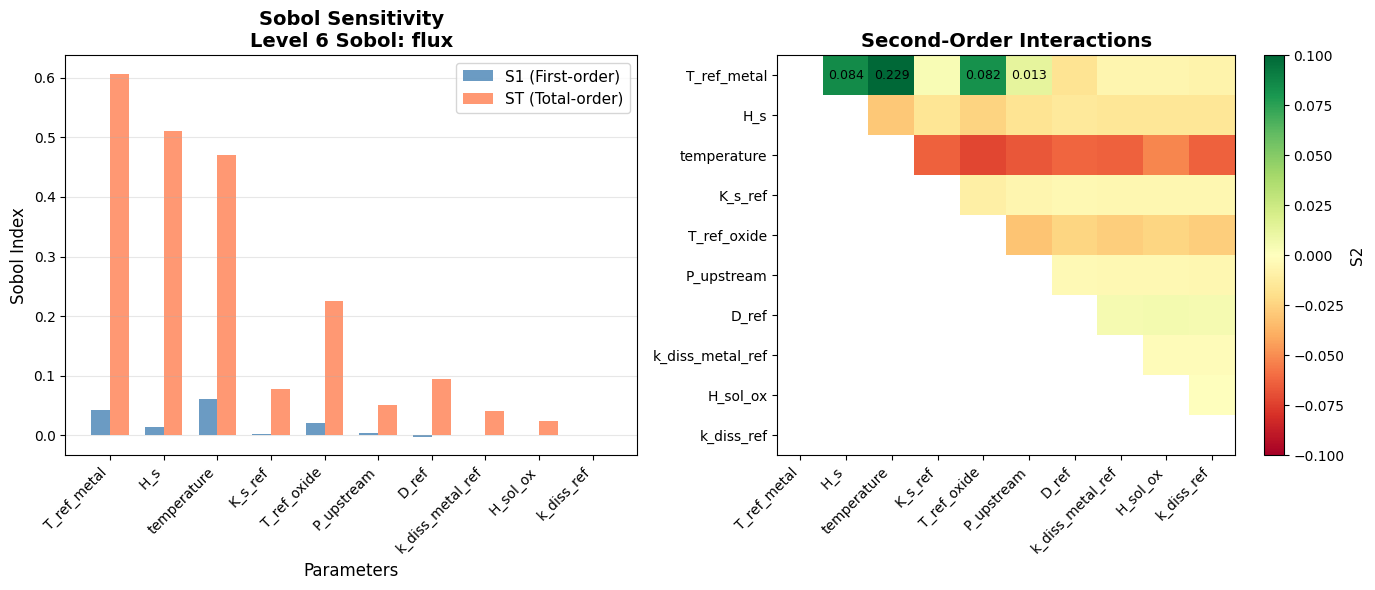


SOBOL SENSITIVITY RESULTS - Level 6 Sobol: flux
       Parameter        S1  S1_conf           ST  ST_conf  Interactions
     T_ref_metal  0.042393 0.101617 6.070871e-01 0.939952      0.564694
             H_s  0.014659 0.017340 5.100488e-01 1.145733      0.495390
     temperature  0.061767 0.072390 4.705514e-01 0.793734      0.408784
         K_s_ref  0.002545 0.004819 7.716880e-02 0.131560      0.074623
     T_ref_oxide  0.021449 0.028688 2.261293e-01 0.675986      0.204680
      P_upstream  0.004254 0.005848 5.034172e-02 0.107903      0.046088
           D_ref -0.002849 0.005507 9.516490e-02 0.256419      0.098014
k_diss_metal_ref  0.000787 0.002292 4.028469e-02 0.086956      0.039498
        H_sol_ox  0.000549 0.002167 2.407283e-02 0.049732      0.023524
      k_diss_ref  0.000002 0.000012 7.860876e-07 0.000002     -0.000001

Interpretation:
  S1   : First-order effect (direct influence)
  ST   : Total-order effect (direct + interactions)
  ST-S1: Pure interaction effects

Top 3 Mo

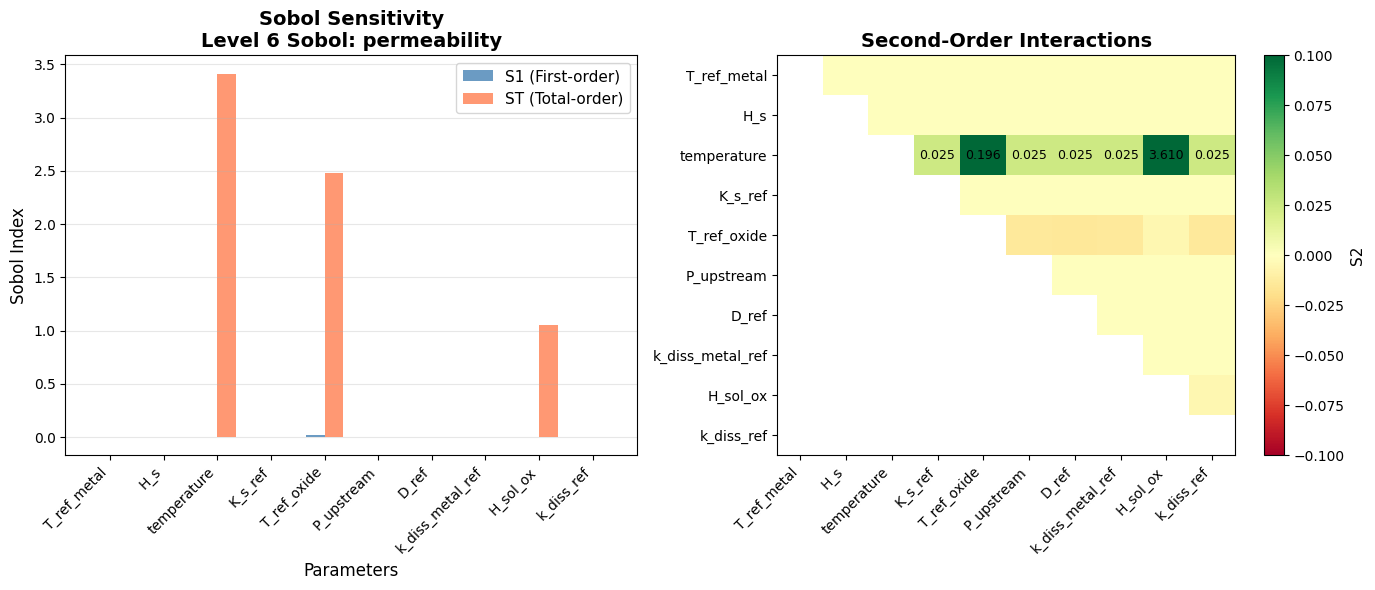


SOBOL SENSITIVITY RESULTS - Level 6 Sobol: permeability
       Parameter            S1      S1_conf           ST      ST_conf  Interactions
     T_ref_metal -2.818538e-04 2.756593e-04 3.189447e-03 3.964987e-03  3.471301e-03
             H_s -7.653073e-05 1.381474e-04 5.017703e-04 9.275578e-04  5.783010e-04
     temperature -6.468844e-04 1.310374e-02 3.413002e+00 5.990723e+00  3.413649e+00
         K_s_ref  1.262233e-04 2.197269e-04 1.399286e-03 2.416539e-03  1.273062e-03
     T_ref_oxide  1.498355e-02 2.340079e-02 2.476459e+00 3.478631e+00  2.461475e+00
      P_upstream  0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00  0.000000e+00
           D_ref  2.136658e-04 2.153159e-04 2.216344e-03 2.594594e-03  2.002678e-03
k_diss_metal_ref  0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00  0.000000e+00
        H_sol_ox -4.376158e-04 7.987432e-03 1.050407e+00 2.189872e+00  1.050845e+00
      k_diss_ref -4.123733e-19 7.631850e-19 1.498155e-32 2.772656e-32  4.123733e-19

Interpretation:
  

In [10]:
# =============================================================================
# PLOT SOBOL RESULTS FOR ALL OUTPUTS
# =============================================================================

for output_metric in VALID_OUTPUT_METRICS_L5L6:
    print(f"\n{'='*70}")
    print(f"OUTPUT: {output_metric}")
    print(f"{'='*70}")
    
    Si = sobol_results[output_metric]['Si']
    problem = sobol_results[output_metric]['problem']
    
    plot_sobol_results(Si, problem, f'Level 6 Sobol: {output_metric}')